# 0.0 Set up

In [1]:
import re
import os, sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import geopandas as gpd
import osmnx as ox
import igraph as ig

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

# Import config and setup
from config import setup_notebook, get_path
setup_notebook()

✓ Project root: /workspace/project_paaral
✓ Working directory: /workspace/project_paaral
✓ Python path updated


{'project_root': PosixPath('/workspace/project_paaral'),
 'data': PosixPath('/workspace/project_paaral/data'),
 'modules': PosixPath('/workspace/project_paaral/modules'),
 'notebooks': PosixPath('/workspace/project_paaral/notebooks'),
 'output': PosixPath('/workspace/project_paaral/output'),
 'psgc_shapefiles': PosixPath('/workspace/project_paaral/data/philippines-psgc-shapefiles/dist')}

In [15]:
import scipy
print(scipy.__version__)

1.16.2


# 1.0 Module

## 1.1 Load modules

In [21]:
from modules import psgc_consolidator
# Reload the module
importlib.reload(psgc_consolidator)

from modules import regional_road_network_extractor
# Reload the module
importlib.reload(regional_road_network_extractor)

<module 'modules.regional_road_network_extractor' from '/workspace/project_paaral/modules/regional_road_network_extractor.py'>

In [22]:
from modules.psgc_consolidator import PSGCConsolidator
from modules.regional_road_network_extractor import RegionalRoadNetworkExtractor

In [4]:
print(regional_road_network_extractor.__doc__)


Regional Road Network Extractor Module

Extracts drive road networks from OpenStreetMap using OSMNx with province-level
querying to handle archipelagic regions reliably.

Author: Claude Code
Date: 2025-10-01

Examples
--------
Basic Setup
~~~~~~~~~~~
>>> from modules.psgc_consolidator import PSGCConsolidator
>>> from modules.regional_road_network_extractor import RegionalRoadNetworkExtractor
>>>
>>> # Load PSGC geographic data
>>> consolidator = PSGCConsolidator(
...     base_dir=r"C:\path	o\philippines-psgc-shapefiles\dist",
...     verbose=False
... )
>>> gdf = consolidator.load_complete_data()
>>>
>>> # Initialize extractor
>>> extractor = RegionalRoadNetworkExtractor(gdf, verbose=True)

List Available Regions and Provinces
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
>>> # Get all regions
>>> regions = extractor.get_region_list()
>>> print(regions)
   region_code              region_name
0           01  Region I (Ilocos Region)
1           02      Region II (Cagayan Valley)
...

>>> # Ge

In [23]:
# Load geographic data (or shapefiles)
consolidator = PSGCConsolidator(
  base_path=get_path('psgc_shapefiles'),
  verbose=False
)
gdf = consolidator.process()

/usr/local/lib/python3.11/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'PH_Adm4_BgySubMuns.shp.zip': 'BgySubMuns.shp' (default), 'PH_Adm4_BgySubMuns.shp'. Specify layer parameter to avoid this warning.
  result = read_func(


In [24]:
display(gdf.head(2))

,psgc_code,corr_code,name,adm4_en_psgc,geometry,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en_shapes,geo_level,len_crs,area_crs,len_km,area_km2
0,0102801001,12801001.0,Adams,Adams (Pob.),"POLYGON ((120.92068 18.51462, 120.94626 18.511...",0100000000,0102800000,0102801000,0102801001,Region I (Ilocos Region),Ilocos Norte,Adams,Adams,Bgy,45997.0,111184551.0,45.0,111.0
1,0102802001,12802001.0,Bani,Bani,"POLYGON ((120.61278 18.2759, 120.61282 18.2758...",0100000000,0102800000,0102802000,0102802001,Region I (Ilocos Region),Ilocos Norte,Bacarra,Bani,Bgy,5982.0,1761135.0,5.0,1.0


## 1.2 Implementation
Extract `drive` regional road networks for a region with provincial breakdown

In [32]:
# Clear cache first to force fresh query
extractor.cache.clear()

# 2. Initialize the extractor
extractor = RegionalRoadNetworkExtractor(gdf, verbose=True)

INFO - Regional Road Network Extractor initialized
INFO:modules.regional_road_network_extractor:Regional Road Network Extractor initialized
INFO - Input GeoDataFrame: 42048 features
INFO:modules.regional_road_network_extractor:Input GeoDataFrame: 42048 features


In [33]:
# 3. See available regions
regions = extractor.get_region_list()
print(regions)

# 4. See provinces in a specific region
provinces = extractor.get_province_list('Central Visayas')
print(provinces)

INFO - Available regions: 18
INFO:modules.regional_road_network_extractor:Available regions: 18
INFO - Available provinces: 4
INFO:modules.regional_road_network_extractor:Available provinces: 4


   region_code                                        region_name
0           00                                                NaN
1           01                           Region I (Ilocos Region)
2           02                         Region II (Cagayan Valley)
3           03                         Region III (Central Luzon)
4           04                           Region IV-A (CALABARZON)
5           05                            Region V (Bicol Region)
6           06                        Region VI (Western Visayas)
7           07                       Region VII (Central Visayas)
8           08                      Region VIII (Eastern Visayas)
9           09                    Region IX (Zamboanga Peninsula)
10          10                       Region X (Northern Mindanao)
11          11                           Region XI (Davao Region)
12          12                          Region XII (SOCCSKSARGEN)
13          13                      National Capital Region (NCR)
14        

### 1.2.1 Region III

In [47]:
# Query entire region (queries all provinces, then merges)
G, metadata = extractor.query_region(
    'Region III',
    buffer_meters=1_000,
    boundary_tolerance_meters=100.0
)

INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Querying region: Region III (Central Luzon) (03)
INFO:modules.regional_road_network_extractor:Querying region: Region III (Central Luzon) (03)
INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Using province-level breakdown (recommended for archipelagic regions)
INFO:modules.regional_road_network_extractor:Using province-level breakdown (recommended for archipelagic regions)
INFO - Found 7 provinces in region
INFO:modules.regional_road_network_extractor:Found 7 provinces in region
INFO - 
[1/7] Processing: Bataan
INFO:modules.regional_road_network_extractor:
[1/7] Processing: Bataan
INFO - Using cached result for 0300800000
INFO:modules.regional_road_network_extractor:Using cache

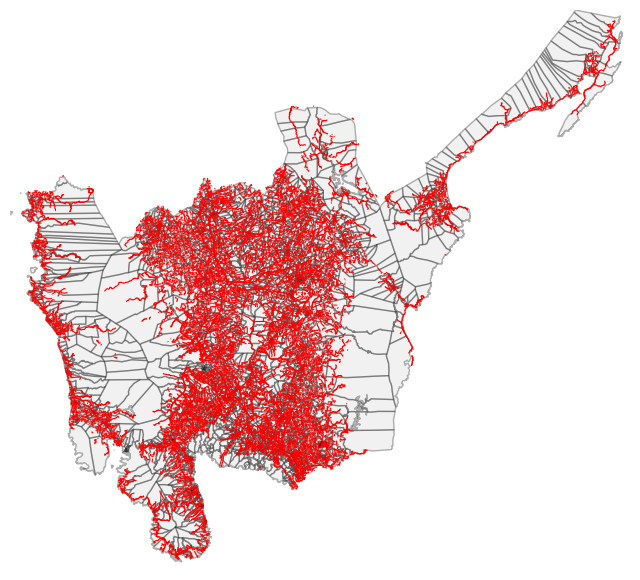

In [48]:
# With background region shapefile
fig, ax = plt.subplots(figsize=(8, 8))

region_gdf = gdf[gdf['psgc_code'].astype('string').str.contains(r'^03')]
region_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.3)

ox.plot_graph(G, ax=ax, node_size=0, edge_color='red', edge_linewidth=0.8, show=False)

outpath = os.path.join(get_path('output'),'regionIII_provBreakdown.png')
plt.savefig(
    outpath, dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()

In [41]:
# Query entire region (queries all provinces, then merges)
G_direct, metadata = extractor.query_region(
    'Region III',
    buffer_meters=5_000, # meters
    use_province_breakdown=False  # Direct query
)

INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Querying region: Region III (Central Luzon) (03)
INFO:modules.regional_road_network_extractor:Querying region: Region III (Central Luzon) (03)
INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Using direct region query (entire shapefile)
INFO:modules.regional_road_network_extractor:Using direct region query (entire shapefile)
INFO - Querying 1 polygon(s)
INFO:modules.regional_road_network_extractor:Querying 1 polygon(s)
INFO - Querying polygon 1/1...
INFO:modules.regional_road_network_extractor:Querying polygon 1/1...
/usr/local/lib/python3.11/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 15 times your configured Overpass max query area size. It will automatical

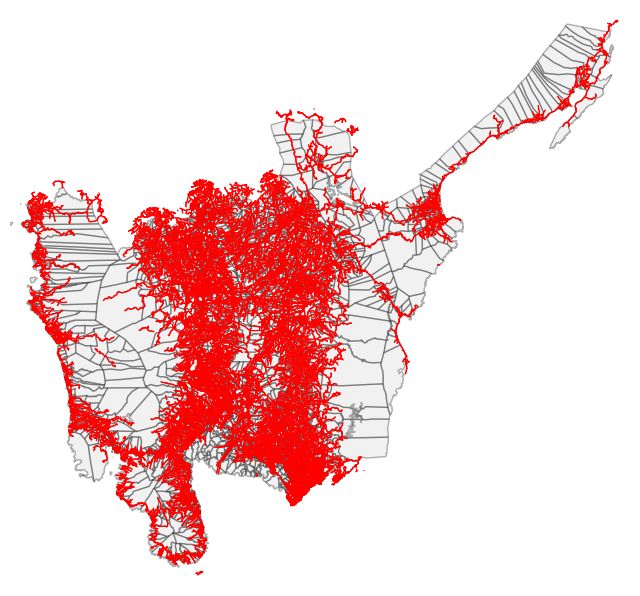

In [42]:
# With background region shapefile
fig, ax = plt.subplots(figsize=(8, 8))

region_gdf = gdf[gdf['psgc_code'].astype('string').str.contains(r'^03')]
region_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.3)

ox.plot_graph(G_direct, ax=ax, node_size=0, edge_color='red', edge_linewidth=0.8, show=False)

# outpath = os.path.join(get_path('output'),'regionIII_direct_1kbuffer.png')
# plt.savefig(
#     outpath, dpi=300,
#     transparent=True,
#     bbox_inches='tight'
# )

plt.show()

In [43]:
# region_data = gdf[gdf['psgc_code'].astype('string').str.contains(r'^03')]
# original_geom = region_data.union_all()

# buffer_degrees = 5000 / 111320
# buffered_geom = original_geom.buffer(buffer_degrees)

# # Plot both
# fig, ax = plt.subplots(figsize=(10, 10))
# gpd.GeoSeries([original_geom]).plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, label='Original')
# gpd.GeoSeries([buffered_geom]).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Buffered')
# plt.legend()
# plt.show()

### 1.2.2 Region VII

In [28]:
# Query entire region (queries all provinces, then merges)
G_r7, metadata = extractor.query_region(
    'Central Visayas',
    boundary_tolerance_meters=20.0
)

INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Querying region: Region VII (Central Visayas) (07)
INFO:modules.regional_road_network_extractor:Querying region: Region VII (Central Visayas) (07)
INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Using province-level breakdown (recommended for archipelagic regions)
INFO:modules.regional_road_network_extractor:Using province-level breakdown (recommended for archipelagic regions)
INFO - Found 4 provinces in region
INFO:modules.regional_road_network_extractor:Found 4 provinces in region
INFO - 
[1/4] Processing: Bohol
INFO:modules.regional_road_network_extractor:
[1/4] Processing: Bohol
INFO - Querying province: Bohol (0701200000)
INFO:modules.regional_road_network_extractor:Queryi

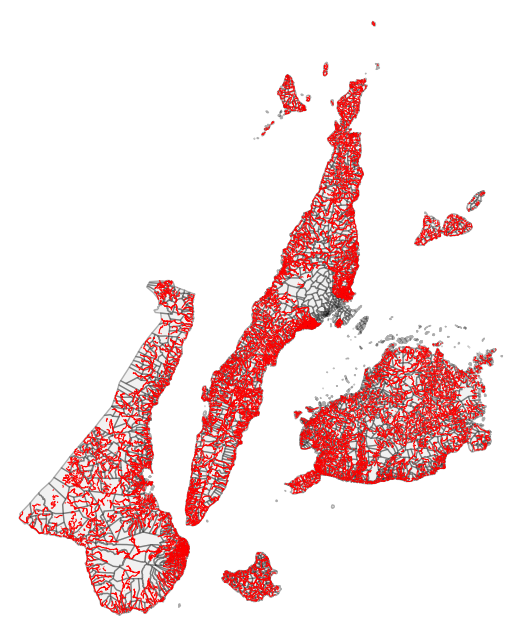

In [29]:
# With background region shapefile
fig, ax = plt.subplots(figsize=(8, 8))

region_gdf = gdf[gdf['psgc_code'].astype('string').str.contains(r'^07')]
region_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.3)

ox.plot_graph(G_r7, ax=ax, node_size=0, edge_color='red', edge_linewidth=0.8, show=False)

outpath = os.path.join(get_path('output'),'regionVII_provBreakdown.png')
# plt.savefig(
#     outpath, dpi=300,
#     transparent=True,
#     bbox_inches='tight'
# )

plt.show()

In [30]:
# Query entire region (queries all provinces, then merges)
G_r7_direct, metadata = extractor.query_region(
    'Central Visayas',
    use_province_breakdown=False  # Direct query
)

INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Querying region: Region VII (Central Visayas) (07)
INFO:modules.regional_road_network_extractor:Querying region: Region VII (Central Visayas) (07)
INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Using direct region query (entire shapefile)
INFO:modules.regional_road_network_extractor:Using direct region query (entire shapefile)
INFO - Querying 108 polygon(s)
INFO:modules.regional_road_network_extractor:Querying 108 polygon(s)
INFO - Querying polygon 1/108...
INFO:modules.regional_road_network_extractor:Querying polygon 1/108...
WARNING -   → Polygon 1 failed: No data elements in server response. Check query location/filters and log.
INFO - Querying polygon 2/108...
INFO:modules

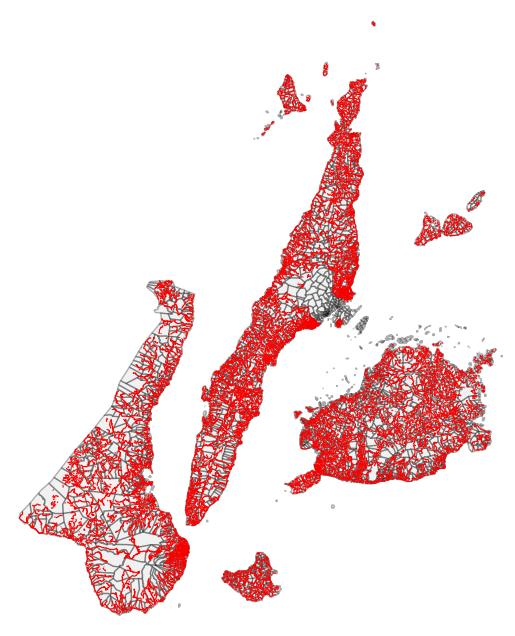

In [31]:
# With background region shapefile
fig, ax = plt.subplots(figsize=(8, 8))

region_gdf = gdf[gdf['psgc_code'].astype('string').str.contains(r'^07')]
region_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.3)

ox.plot_graph(G_r7_direct, ax=ax, node_size=0, edge_color='red', edge_linewidth=0.8, show=False)

outpath = os.path.join(get_path('output'),'regionVII_provBreakdown.png')
# plt.savefig(
#     outpath, dpi=300,
#     transparent=True,
#     bbox_inches='tight'
# )

plt.show()

## 1.3 Config B
Extract `drive` regional drive network using direct method (using entire regional shapefile <b>without</b> provincial breakdown).

In [13]:
psgc_str = '07'
# Query entire region directly (faster but may miss islands)
G_direct, meta_direct = extractor.query_region(
    psgc_str,
    use_province_breakdown=False  # Direct query
)

INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Querying region: Region VII (Central Visayas) (07)
INFO:modules.regional_road_network_extractor:Querying region: Region VII (Central Visayas) (07)
INFO - ============================================================
INFO:modules.regional_road_network_extractor:============================================================
INFO - Using direct region query (entire shapefile)
INFO:modules.regional_road_network_extractor:Using direct region query (entire shapefile)
INFO - Querying 108 polygon(s)
INFO:modules.regional_road_network_extractor:Querying 108 polygon(s)
INFO - Querying polygon 1/108...
INFO:modules.regional_road_network_extractor:Querying polygon 1/108...
WARNING -   → Polygon 1 failed: No data elements in server response. Check query location/filters and log.
INFO - Querying polygon 2/108...
INFO:modules

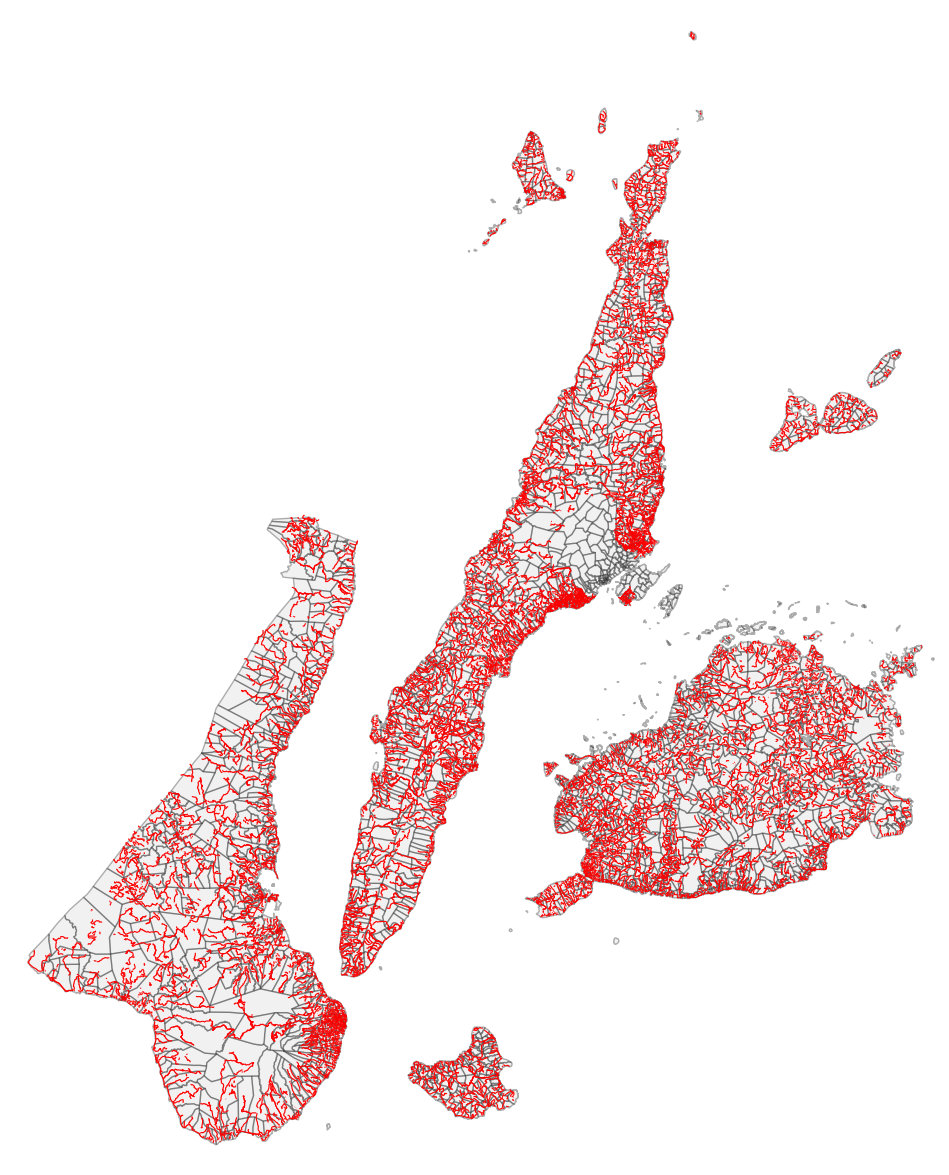

In [15]:
# With background region shapefile
fig, ax = plt.subplots(figsize=(15, 15))

region_gdf = gdf[gdf['psgc_code'].astype('string').str.contains(r'^'+psgc_str)]
region_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.3)

ox.plot_graph(G_direct, ax=ax, node_size=0, edge_color='red', edge_linewidth=0.8, show=False)
plt.show()